In [76]:
import matplotlib
import os
import sys
sys.path.append('..')
from er_simulator.wc_model import WCTaskSim
from er_simulator.functions import resample_signal
from er_simulator.synaptic_weights_matrices import normalize, generate_synaptic_weights_matrices
from er_simulator.read_utils import generate_sw_matrices_from_mat
from er_simulator.load_wc_params import load_wc_params
from er_simulator import functions
from er_simulator.boldIntegration import BWBoldModel
import numpy as np
from tqdm import tqdm 
from tqdm import trange
import matplotlib.pyplot as plt
from scipy import signal, stats, io
from scipy.io import savemat
from er_simulator.read_utils import get_project_root


matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 10
plt.rcParams['image.cmap'] = 'plasma'
np.set_printoptions(suppress=True)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [77]:
N = 1 # Sample size
microtime = 2/16
design = "small_07_EVENT_[2s_TR]_[100ms_DUR]_[6s_ISI]_[100_TRIALS]_[COACT]";
HRF_type = "[FixedHRF]"; # [VarHRF]

results_folder = f'{design}_{HRF_type}'
mat_path = os.path.join('..', '02_designs', f'{design}.mat')
config_file = os.path.join('..', '01_configs', f'{results_folder}.yaml')

In [92]:
%%time
wc_sim = WCTaskSim.from_config(config_file)
wc_sim.generate_full_series(compute_bold=True)

CPU times: user 28.1 s, sys: 1.92 s, total: 30 s
Wall time: 28.6 s


In [115]:
#compute envelopes for task
env_dict = wc_sim.compute_envelope_and_resample(wc_sim.output['syn_act'], srate=wc_sim.mTime, microtime=microtime)
task_BOLD_oscill_MT,_ = resample_signal(wc_sim.output['mtime'], wc_sim.output["BOLD"], wc_sim.mTime, microtime)
print(env_dict.keys())
print(wc_sim.output["BOLD"].shape, task_BOLD_oscill_MT.shape, env_dict['e_hil_d2'].shape)

dict_keys(['e_hil_d2', 'e_hil_d5', 'e_peak_600', 'e_peak_1000'])
(100, 17100) (100, 684) (100, 684)


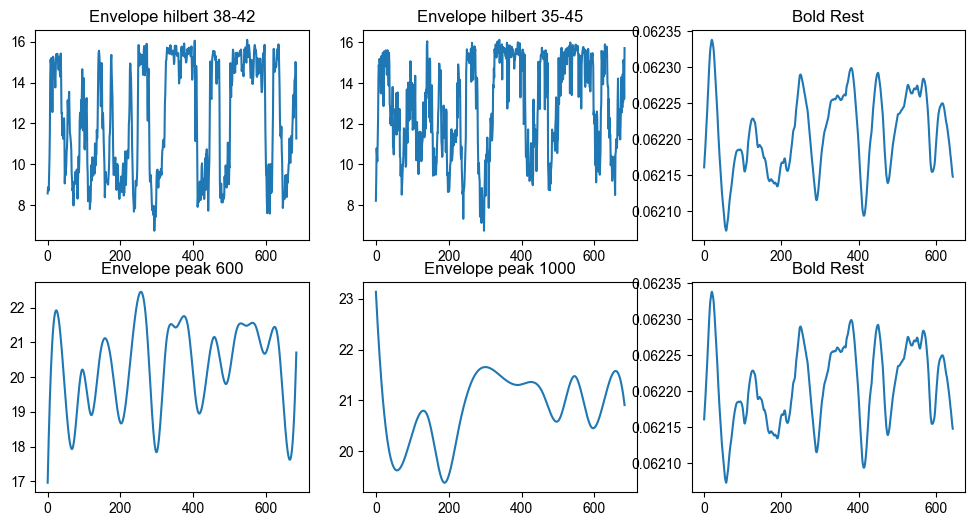

In [122]:
plt.figure(figsize = (12,6))
plt.subplot(231); plt.plot(env_dict['e_hil_d2'][0,:].T); plt.title("Envelope hilbert 38-42")
plt.subplot(232); plt.plot(env_dict['e_hil_d5'][0,:].T); plt.title("Envelope hilbert 35-45")
plt.subplot(233); plt.plot(task_BOLD_oscill_MT[0,40:].T); plt.title("Bold Rest")
plt.subplot(234); plt.plot(env_dict['e_peak_600'][0,:].T); plt.title("Envelope peak 600")
plt.subplot(235); plt.plot(env_dict['e_peak_1000'][0,:].T); plt.title("Envelope peak 1000")
plt.subplot(236); plt.plot(task_BOLD_oscill_MT[0,40:].T); plt.title("Bold Rest");

In [116]:
%%time
time_coact_mTime,_,task_BOLD_coact_mTime = wc_sim.generate_coactivation_by_mat(wc_sim.mat_path, dt=None, normalize_constant=1)
task_BOLD_coact_MT,_ =  resample_signal(time_coact_mTime, task_BOLD_coact_mTime, wc_sim.mTime, microtime)
len(task_BOLD_coact_mTime[0]), len(task_BOLD_coact_MT[0])

CPU times: user 140 ms, sys: 5.32 ms, total: 145 ms
Wall time: 146 ms


(17100, 684)

In [87]:
%%time
# Generate rest time-series in 5 ms resolution
output_rest = wc_sim.generate_rest_series(compute_bold=True, rest_duration=30)

CPU times: user 15.1 s, sys: 1.09 s, total: 16.2 s
Wall time: 15.7 s


In [118]:
env_dict_rest = wc_sim.compute_envelope_and_resample(output_rest['syn_act'], srate=wc_sim.mTime, microtime=microtime)
rest_BOLD_oscill_MT,_ = resample_signal(output_rest['mtime'], output_rest["BOLD"], wc_sim.mTime, microtime)
print(env_dict_rest.keys())


dict_keys(['e_hil_d2', 'e_hil_d5', 'e_peak_600', 'e_peak_1000'])


Text(0.5, 1.0, 'Bold Rest')

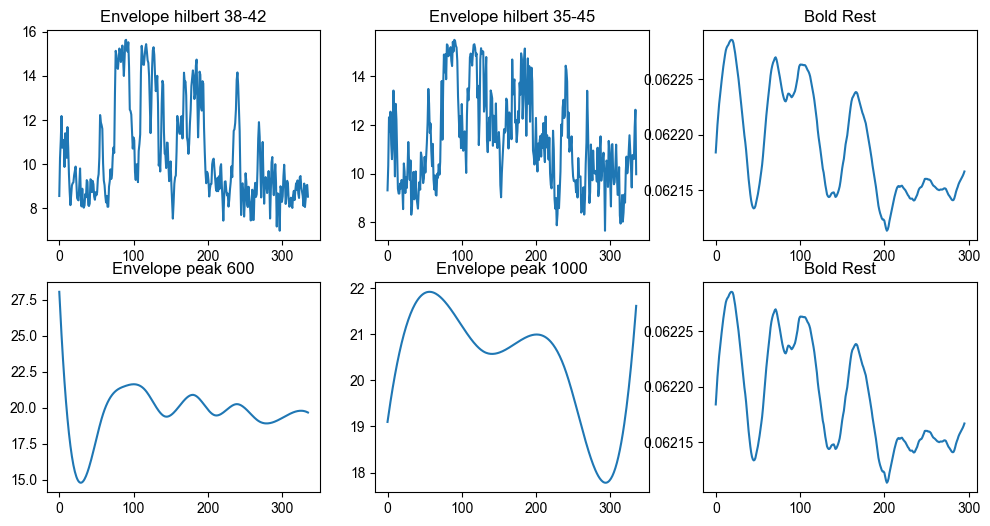

In [120]:
plt.figure(figsize = (12,6))
plt.subplot(231); plt.plot(env_dict_rest['e_hil_d2'][0,:].T); plt.title("Envelope hilbert 38-42")
plt.subplot(232); plt.plot(env_dict_rest['e_hil_d5'][0,:].T); plt.title("Envelope hilbert 35-45")
plt.subplot(233); plt.plot(rest_BOLD_oscill_MT[0,40:].T); plt.title("Bold Rest")
plt.subplot(234); plt.plot(env_dict_rest['e_peak_600'][0,:].T);plt.title("Envelope peak 600")
plt.subplot(235); plt.plot(env_dict_rest['e_peak_1000'][0,:].T); plt.title("Envelope peak 1000")
plt.subplot(236); plt.plot(rest_BOLD_oscill_MT[0,40:].T); plt.title("Bold Rest")

In [129]:
# as a result for saving
dict_to_save = {**env_dict_rest, **env_dict, 
'task_BOLD_oscill_MT': task_BOLD_oscill_MT,
'BOLD_coact_MT':  task_BOLD_coact_MT,
'rest_BOLD_oscill_MT': rest_BOLD_oscill_MT}
dict_to_save.keys()
#maybe to TR also? 

dict_keys(['e_hil_d2', 'e_hil_d5', 'e_peak_600', 'e_peak_1000', 'task_BOLD_oscill_MT', 'BOLD_coact_MT', 'rest_BOLD_oscill_MT'])

In [43]:
for i in trange(N):
    
    # Create subject folder
    os.makedirs(os.path.join('..', '03_results', results_folder, fr'{i+1:03d}_Subject'), exist_ok=True)
    
    # Load simulation parameters from config file
    wc_sim = WCTaskSim.from_config(config_file)

    # Save HRF parameters
    wc_sim.boldModel.save_imp_with_params(os.path.join(fr'..', 
                                                       '03_results',
                                                       results_folder, 
                                                       fr'{i+1:03d}_Subject',
                                                       'HRF_params.mat'), s_type='mat')

    # Generate task time-series in 5 ms resolution
    wc_sim.generate_full_series(compute_bold=True)
    output_task = wc_sim.output.copy()

    # Downsample task BOLD to Micro-Time resolution = TR/16  
    task_BOLD_oscill_MT,_ = resample_signal(output_task['mtime'], output_task["BOLD"], wc_sim.mTime, microtime)

    # Generate co-activations in high resolution 10 ms
    time_coact,_,task_BOLD_coact_10ms = wc_sim.generate_coactivation_by_mat(wc_sim.mat_path, dt=0.005, normalize_constant=1)

    # Downsample co-activations to Micro-Time resolution = TR/16  
    task_BOLD_coact_MT,_ =  resample_signal(time_coact, task_BOLD_coact_10ms, 0.010, microtime)
    
    # Generate rest time-series in 5 ms resolution
    output_rest = wc_sim.generate_rest_series(compute_bold=True)

    # Downsample rest BOLD to Micro-Time resolution = TR/16
    rest_BOLD_oscill_MT,_ = resample_signal(output_rest['mtime'], output_rest["BOLD"], wc_sim.mTime, microtime)

    # Save time-series
    savemat(os.path.join(fr'..',
                         '03_results',
                         results_folder,
                         fr'{i+1:03d}_Subject',
                         'time_series.mat'),
                          {'task_syn_act_5ms':    output_task['syn_act'],
                           'task_BOLD_oscill_MT': task_BOLD_oscill_MT,
                           'BOLD_coact_MT':       task_BOLD_coact_MT,
                           'rest_syn_act_5ms':    output_rest['syn_act'],
                           'rest_BOLD_oscill_MT': rest_BOLD_oscill_MT}) 
    
    # Clear
    del output_task, task_BOLD_oscill_MT, task_BOLD_coact_MT, output_rest, wc_sim 
    

100%|███████████████████████████████████████████████████████████████████████████████████| 1/1 [08:12<00:00, 492.53s/it]
